This notebook calculates volume of phases (oil, water, microemulsion), plots phase volumes and boundaries 

In [2]:
import rdkit
from rdkit import Chem
from rdkit.Chem.Descriptors import MolWt
import numpy as np
from functions_for_surfactants import HLD_calculation
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets 
from itertools import product
from functions_for_surfactants import draw_tubes_volumes, xi_calculation
p1 = '[CX4H3][CX4H2]'
p2 = '[CX4H3][CX4H1]([#6])[#6]'
secondary = '[CX4H2]'
tertiary_2 = '[CH3][CH1;X4]([CH3])'
tertiary = '[CH1;X4]'
benzene = 'c1ccccc1'
EO = 'O[CH2][CH2]O'
PO = 'OC(C)CO'

**Enter parameters of the surfactant, its concentration and $\xi$**

Enter SMILES of your surfactant CCCCCCCCCCCC[N+](C)(C)C


Molecular weiight of the molecule is 228.44399999999996
Tail length is 21.684 Å


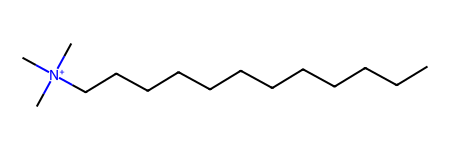

In [3]:
smi = input('Enter SMILES of your surfactant')
mol = Chem.MolFromSmiles(smi)


n_tertiary = len(mol.GetSubstructMatches(Chem.MolFromSmarts(tertiary)))
n_tertiary_2 = len(mol.GetSubstructMatches(Chem.MolFromSmarts(tertiary_2)))
n_PO = len(mol.GetSubstructMatches(Chem.MolFromSmarts(PO)))
n_EO = len(mol.GetSubstructMatches(Chem.MolFromSmarts(EO)))
n_p1 = len(mol.GetSubstructMatches(Chem.MolFromSmarts(p1)))
n_p2 = len(mol.GetSubstructMatches(Chem.MolFromSmarts(p2)))

n_secondary = len(mol.GetSubstructMatches(Chem.MolFromSmarts(secondary)))
n_benzene = len(mol.GetSubstructMatches(Chem.MolFromSmarts(benzene)))
n_tertiary_non_2 = n_tertiary-n_tertiary_2-n_PO

number_of_carbons = (n_p1 + n_p2 +n_secondary)+6.9*n_tertiary_2 + 0.71 * n_tertiary_non_2 +3.5 * n_benzene
Lc = 1.5 + 1.265 * number_of_carbons
L = 1.3 * Lc
MWt = MolWt(mol)
print('Molecular weiight of the molecule is {}'.format(MWt))
print('Tail length is {} Å'.format(L))

mol

In [6]:
surfactant_selection = widgets.Dropdown(options = ['', 'Ionic', 'Nonionic'], value = '')
surfactant_selection

Dropdown(options=('', 'Ionic', 'Nonionic'), value='')

Enter weight concentration

In [8]:
wt_concentration = (float(input('Enter weight concentrationof the surfactant')))
mol_concentration = ((1000 * wt_concentration / 100)/MWt)/1000

Enter weight concentrationof the surfactant 2


Calculate $\xi$ here 

In [12]:
MWt_oil = float(input('Molecular weight of the oil'))
density = float(input('Density of the oil, g/cc'))
interfacial_area = float(input(r'Interfacial area Å2'))
xi = xi_calculation(L, interfacial_area, density, MWt_oil, surfactant_type=surfactant_selection.value)
print('Automatically calculated ξ is {}'.format(xi))

Molecular weight of the oil 104
Density of the oil, g/cc 0.76
Interfacial area Å2 45


Automatically calculated ξ is 172.02169522369732


Enter ξ manually, if you don't want automatic calculations

In [85]:
xi = float(input('Your manual value of ξ'))

Interfacial area Å2 45
ξ 209


Enter volumes of water and oil

In [16]:
Vw = (float(input('Enter volume of water, mL ')))
Vo = (float(input('Enter volume of oil, mL ')))
Vs = (wt_concentration/100)*Vw

As =  Vw*mol_concentration*6E23*interfacial_area/1E24  
Rw_ref = 3*Vw/As
Ro_ref = 3*Vo/As

Enter volume of water, mL  5
Enter volume of oil, mL  5


**Enter HLD parameters**

In [18]:
variable_selection = widgets.Dropdown(options = ['', 'Cc', 'EACN', 'Salinity', 'Temperature'], value = '')
variable_selection

Dropdown(options=('', 'Cc', 'EACN', 'Salinity', 'Temperature'), value='')

In [20]:
varied_value = (float(input('Enter first range value of {}'.format(variable_selection.value))), 
                float(input('Enter end range value of {}'.format(variable_selection.value))))
varied_value_range = np.linspace(varied_value[0], varied_value[1], 20)

Enter first range value of Salinity 1
Enter end range value of Salinity 5


In [28]:
if variable_selection.value == 'EACN':
    Cc = float(input('Enter Cc value'))
    Sal = float(input('Enter salinity value'))
    Temp = float(input('Enter temperature value'))
elif variable_selection.value == 'Cc':
    EACN = float(input('Enter EACN value'))
    Sal = float(input('Enter salinity value'))
    Temp = float(input('Enter temperature value'))
elif variable_selection.value == 'Temperature':
    Cc = float(input('Enter Cc value'))
    Sal = float(input('Enter salinity value'))
    EACN = float(input('Enter EACN value'))
elif variable_selection.value == 'Salinity':
    Cc = float(input('Enter Cc value'))
    Temp = float(input('Enter temperature'))
    EACN = float(input('Enter EACN value'))

Enter Cc value -1
Enter temperature 27
Enter EACN value 8


In [30]:
if variable_selection.value == 'EACN':
    HLDs = HLD_calculation(EACN = varied_value_range, Cc = Cc, Sal = Sal, Temp = Temp, Type = surfactant_selection.value)
elif variable_selection.value == 'Cc':
    HLDs = HLD_calculation(EACN = EACN, Cc = varied_value_range, Sal = Sal, Temp = Temp, Type = surfactant_selection.value)
elif variable_selection.value == 'Temperature':
    HLDs = HLD_calculation(EACN = EACN, Cc = Cc, Sal = Sal, Temp = varied_value_range, Type = surfactant_selection.value)
elif variable_selection.value == 'Salinity':
    HLDs = HLD_calculation(EACN = EACN, Cc = Cc, Sal = varied_value_range, Temp = Temp, Type = surfactant_selection.value)

Calculation of relative volume of phases

In [34]:
#calculation of NACs and emulsion types
Hs = -(HLDs/L)
Ros = np.zeros((len(Hs)), dtype = 'float')
Rws = np.zeros((len(Hs)), dtype = 'float')


for i,H in enumerate(Hs):
    if H > 0:
        Rw = Rw_ref
        Ro = 1/(H+1/Rw)
    else:
        Ro = Ro_ref
        Rw = 1/(np.abs(H)+1/Ro)
    Ros[i] = Ro
    Rws[i] = Rw

NACs = 0.5*((1/Ros)+(1/Rws))
NACs_bin = (Ros > Rws).astype(int)
NACs_bin[NACs<1/xi] = 2

Calculation of oil and water volumes in ME, volumes of phases and fractions

In [36]:
mask = NACs_bin==2
Rome  = Ros
Rwme = Rws

Rwme[mask] = 1/((HLDs[mask]/(2*L))+1/xi)
Rome[mask] = 1/(1/Rwme[mask] - (HLDs[mask]/L))
Vome = Rome*As/3
Vwme = Rwme*As/3
Vtot = Vome + Vwme

# Calculation of volume fractions of oil and water in ME
phio = np.zeros(20)
phiw = np.zeros(20)

for i in range(20):
    if HLDs[i] < 0:
        phio[i] = Vome[i]/Vtot[i]
        phiw[i] = 1 - phio[i]
    else:
        phiw[i] = Vwme[i]/Vtot[i]
        phio[i] = 1 - phiw[i]

#calculation of volume of oil, water and ME
Vo_range = np.zeros(20)
Vw_range = np.zeros(20)
Vme_range = np.zeros(20)

for i in range(20):
    if NACs_bin[i] == 0:
        Vo_range[i] = Vo - Vome[i]
        Vw_range[i] = Vw + Vs + Vome[i] 
    elif NACs_bin[i] == 1:
        Vo_range[i] = Vo + Vs + Vwme[i]
        Vw_range[i] = Vw - Vwme[i]
    elif (NACs_bin[i] == 2):
        Vo_range[i] = Vo - Vome[i]
        Vw_range[i] = Vw - Vwme[i]
        Vme_range[i] = Vs + Vome[i] + Vwme[i]

#Calculation of voume fractions of oil, water and ME       
Vt = Vo_range+Vw_range+Vme_range
fr_o = Vo_range/Vt 
fr_w = Vw_range/Vt
fr_me = Vme_range/Vt  

#Boundaries calculatuion
boundary_1 = np.zeros(20)
boundary_2 = np.zeros(20)

for i in range(20):
    if fr_me[i] > 0:
        boundary_1[i] = fr_w[i] + fr_me[i]
        boundary_2[i] = fr_w[i]
    else:
        if fr_w[i] > fr_o[i]:
            boundary_1[i] = fr_w[i]
            boundary_2[i]  = 0
        else:
            boundary_2[i] = fr_w[i]
            boundary_1[i] = 1
            
        

Plotting volumes of oil and water in ME

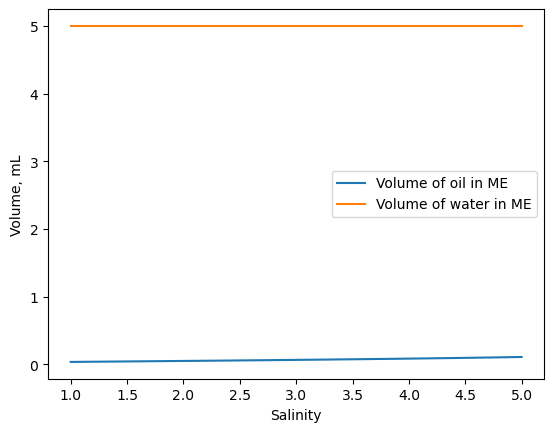

In [38]:
plt.plot(varied_value_range, Vome, label = 'Volume of oil in ME')
plt.plot(varied_value_range, Vwme, label = 'Volume of water in ME')
plt.xlabel(variable_selection.value)
plt.ylabel('Volume, mL')
plt.legend()

Plotting volumes of oil, water and ME in system

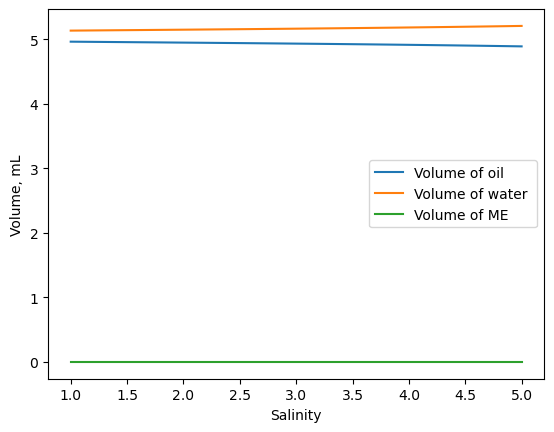

In [40]:
plt.plot(varied_value_range, Vo_range, label = 'Volume of oil')
plt.plot(varied_value_range, Vw_range, label = 'Volume of water ')
plt.plot(varied_value_range, Vme_range, label = 'Volume of ME ')
plt.xlabel(variable_selection.value)
plt.ylabel('Volume, mL')
plt.legend()

Plotting ME upper and lower boundaries

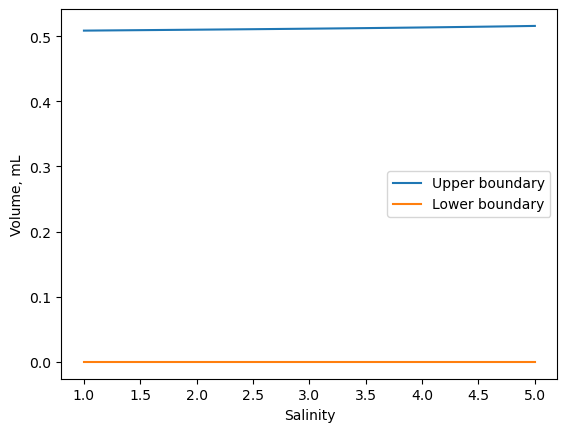

In [42]:
plt.plot(varied_value_range, boundary_1, label = 'Upper boundary')
plt.plot(varied_value_range, boundary_2, label  ='Lower boundary')
plt.xlabel(variable_selection.value)
plt.ylabel('Volume, mL')
plt.legend()


Plotting tubes

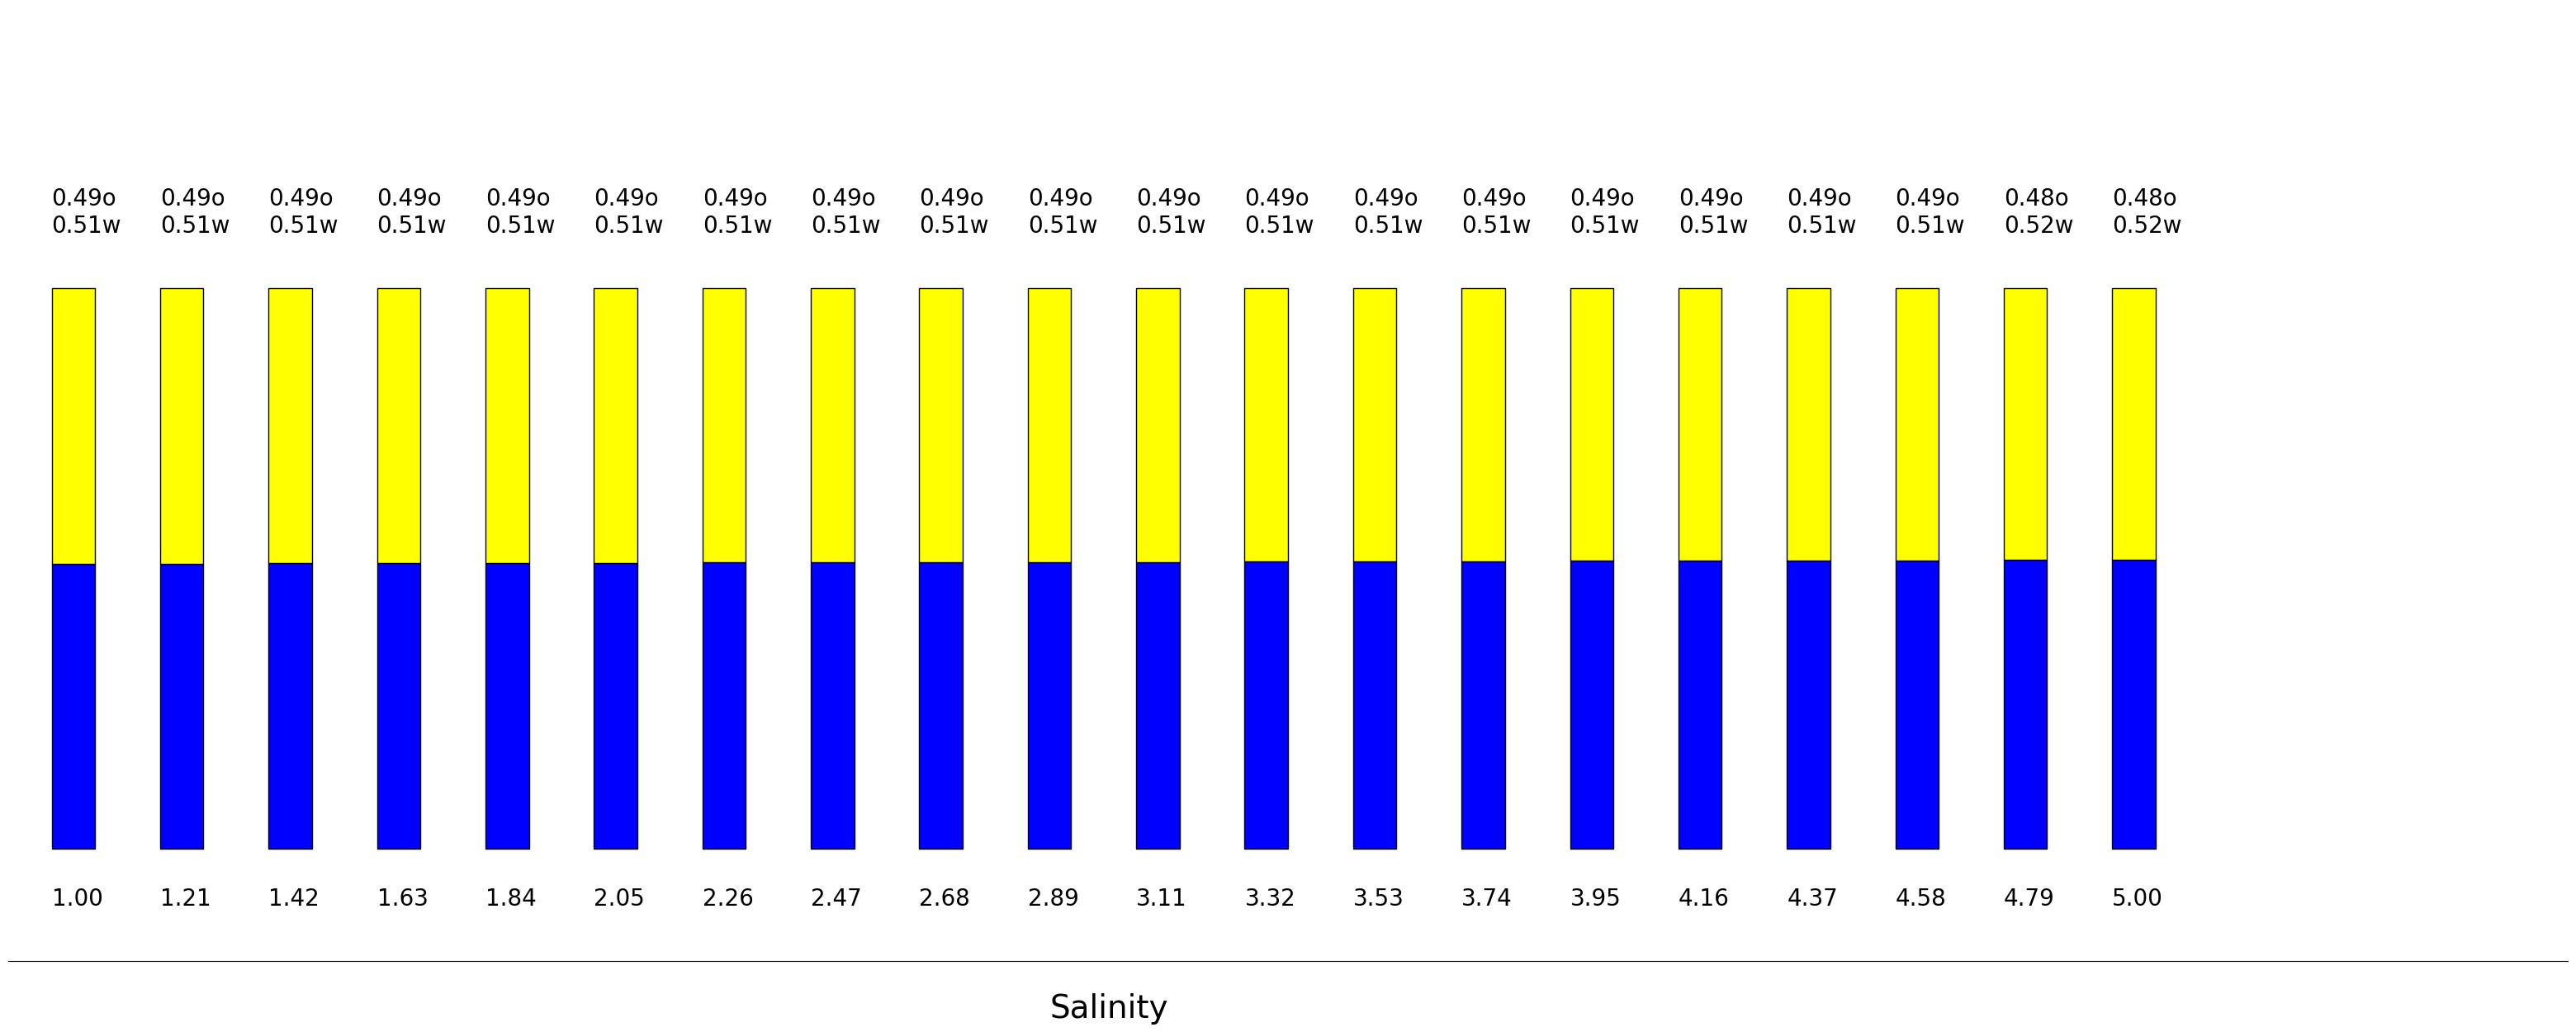

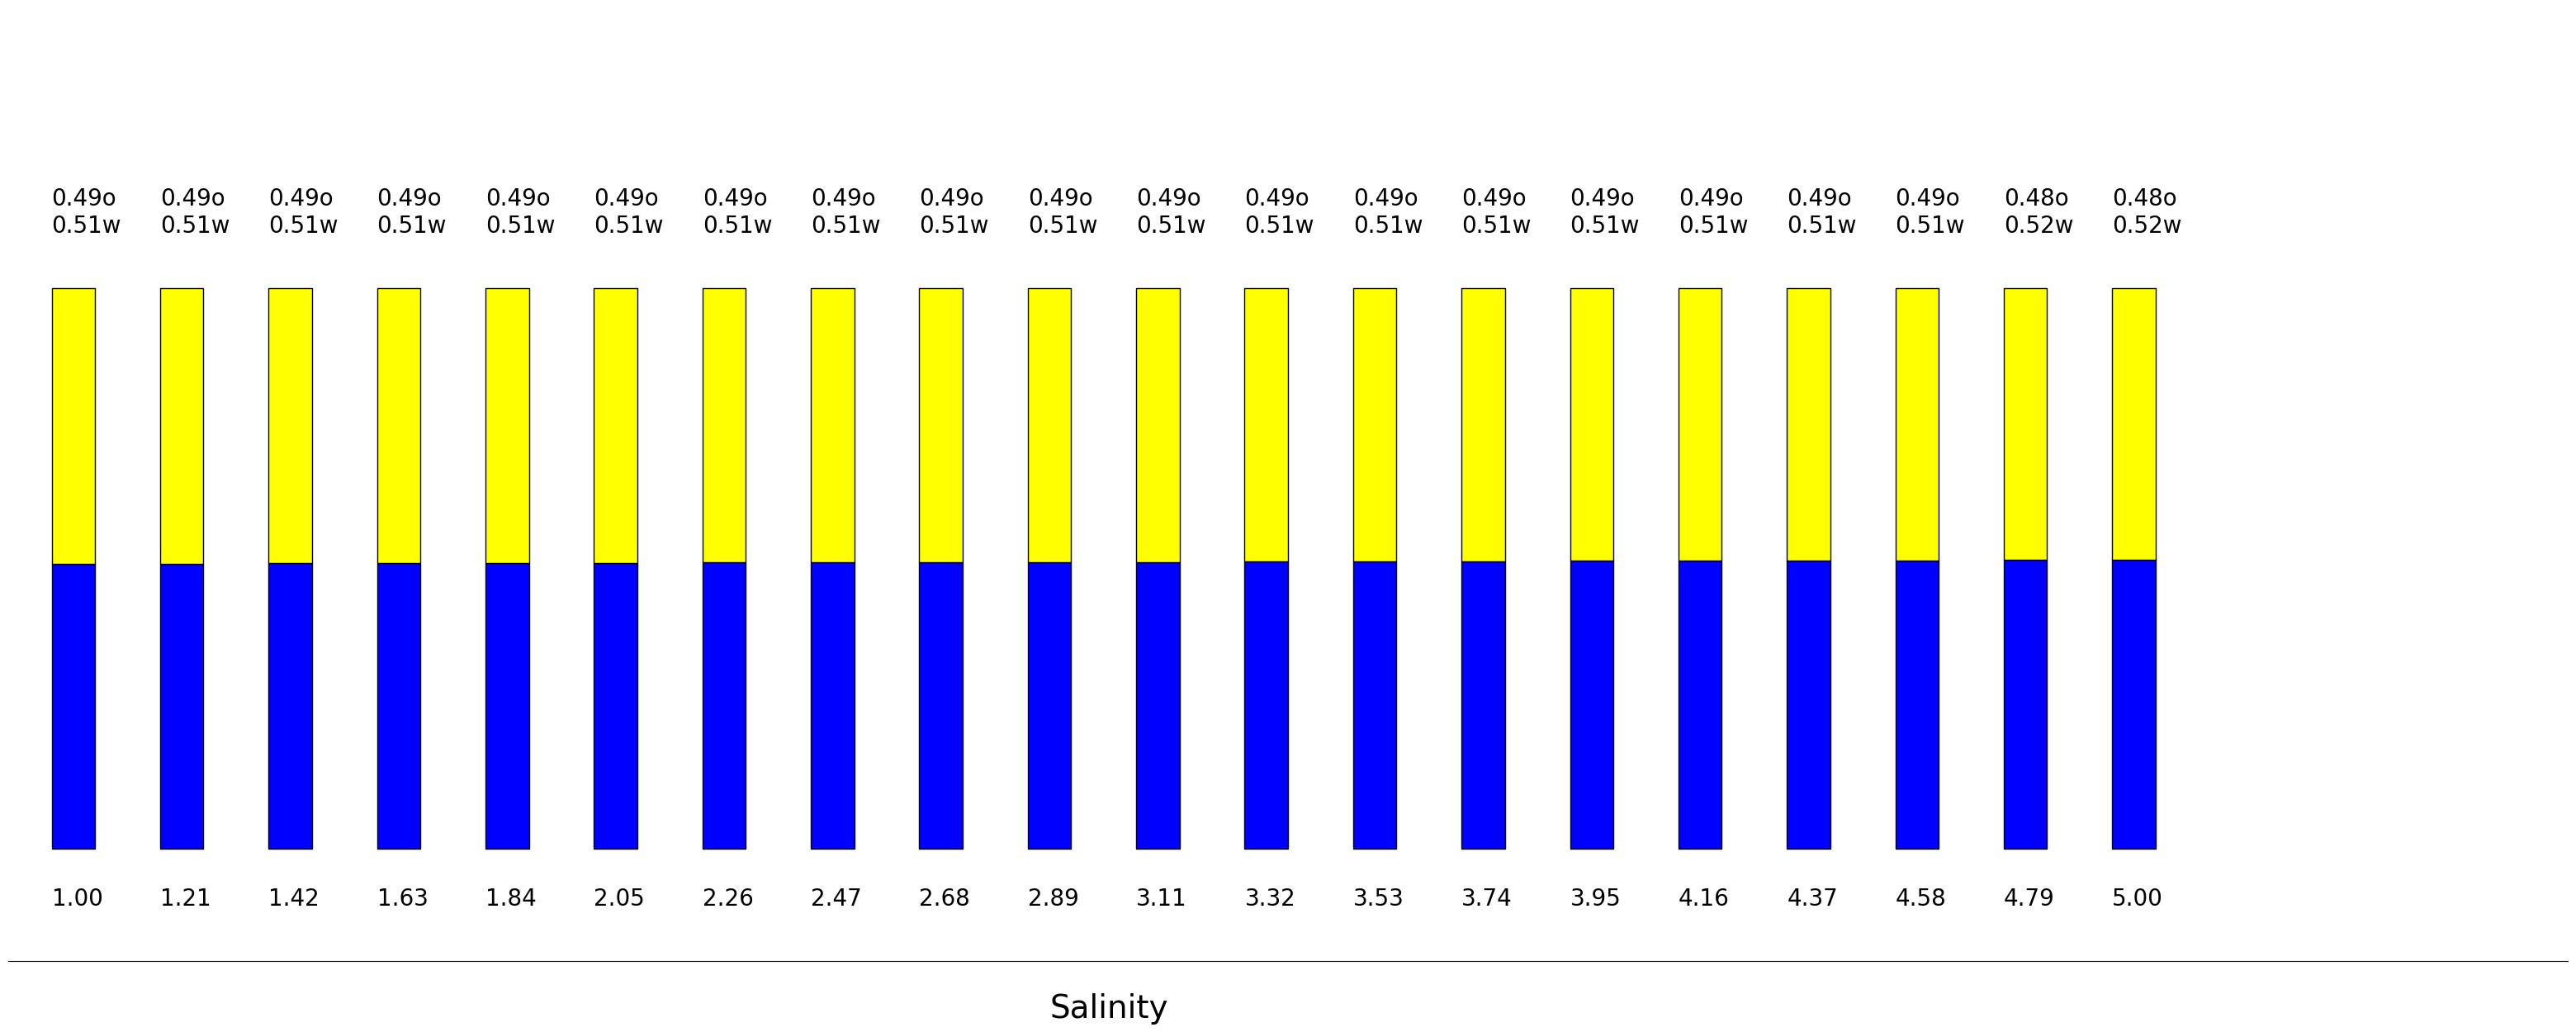

In [44]:
draw_tubes_volumes(boundary_1, boundary_2, fr_o, fr_w, fr_me, varied_value_range, variable_selection.value)